<a href="https://colab.research.google.com/github/saradom11/Simulaci-n-I/blob/main/Prueba_de_los_promedios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Prueba de los Promedios**

La *prueba de los promedios* es un método que nos ayuda a determinar si un conjunto de números aleatorios sigue una distribución uniforme en $[0,1]$, mediante esta prueba sabemos que, si los números son aleatorios la media es cercana a $0.5$

In [7]:
#Importamos las bibliotecas
import numpy as np
import scipy.stats as stats
from scipy.stats import norm
from math import sqrt
import pandas as pd
import matplotlib.pyplot as plt

Las hipotesis son: $$H_0= \mu = \frac{1}{2}$$ $$H_0= \mu \neq \frac{1}{2}$$

La fomula para el estadistico de prueba es:
$$ \frac{(\bar{x} - \frac{1}{2})\sqrt{N}}{\sqrt{\frac{1}{12}}}$$

In [8]:
def prueba_promedios (datos): #Definimos la función para la Prueba de Promedios, el parámetro datos será7n los numeros aleatorios
  alfa=0.05
  N=len(datos)
  media=np.mean(datos)

 #Calculamos el estadistico de prueba
  z_0=(media - 0.5)*sqrt(N)/sqrt(1/12)   # Fórmula: Z_0 = (promedio_muestral - 1/2) / (1 / sqrt(12 * n))

 #Buscamos el valor critico
  z_c=norm.ppf(1 -alfa /2)

 #Determinamos la aceptación o rechazo
  rechazo=abs(z_0)> z_c

  #Valores que queremos nos regrese la función
  return {"N":N, "media":media, "z_0":z_0, "rechazo":rechazo, "z_c":z_c}

<img src="https://lh3.googleusercontent.com/drive-storage/AJQWtBNxz3oALIiO98iBf4tf6NTb9MgSX3PBpt0qPOXPv_2zT8gaTk_Ct7Xgohkr9_hNsYuLwHybJYRZxQtqbTGYDVS-OMJ6p_Hw4TYo1eIFnqn1y7DbdA=w1852-h870?auditContext=forDisplay" width="400" height="400">


In [9]:
df=pd.read_excel("datos_prueba_promedios.xlsx") #Aquí cargamos el archivo de excel con los datos
datos=df['Datos'].dropna().values   #Lo pasamos a un arreglo, la columna con el nombre 'Datos' es donde deben de estar todos los números


#Ejecutamos la prueba e imprimimos los resultados obtenidos en la "Prueba de los promedios"
resultado=prueba_promedios(datos)
print(f"--- Resultados Prueba de Promedios ---")
print(f"Tamaño de la muestra: {resultado['N']}")
print(f"Media obtenida: {resultado['media']:.4f}")
print(f"Estadístico Z calculado: {resultado['z_0']:.4f}")

if resultado["rechazo"]:
    print("Rechazamos H_0 (hipótesis nula) → los datos no parecen uniformes")
else:
    print("Aceptamos H_0 (hipótesis nula) → los datos parecen uniformes")

--- Resultados Prueba de Promedios ---
Tamaño de la muestra: 100
Media obtenida: 0.4822
Estadístico Z calculado: -0.6151
Aceptamos H_0 (hipótesis nula) → los datos parecen uniformes


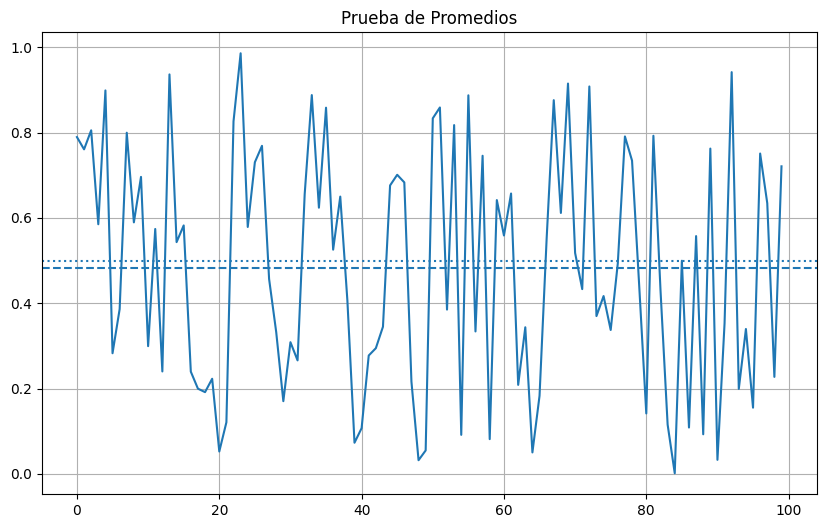

In [13]:
resultado = prueba_promedios(datos)
media = resultado["media"]

plt.figure(figsize=(10,6)) # Tamaño de la gráfica

plt.plot(datos) # Graficar datos

plt.axhline(media, linestyle='--') # Línea de la media obtenida

plt.axhline(0.5, linestyle='dotted') # Línea de la media esperada

plt.title("Prueba de Promedios")
plt.grid()
plt.show()